Energy difference (ortho - meta) at each step: [ 1.6857946   0.34634557 -1.67042432 -4.07591023 -6.68618392]
Energy difference (para - meta) at each step: [ 2.59483771  0.4384526  -2.44297157 -5.34707738 -8.06508578]
Lambda magnitudes: [0.02 0.04 0.06 0.08 0.1 ]


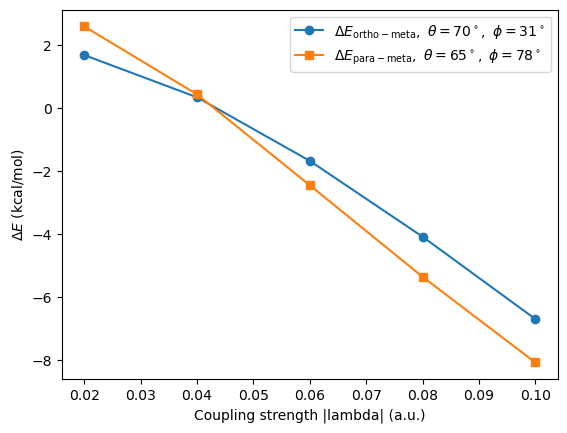

In [8]:
import numpy as np
import matplotlib.pyplot as plt

HARTREE_TO_KCAL = 627.509474

energies_meta_7031 = [-3010.5278615072, -3010.5008974806 ,-3010.4568657235, -3010.3968816104, -3010.3219755384]
E_meta = np.array(energies_meta_7031)

energies_ortho_7031 = [-3010.5251750225,-3010.5003455438, -3010.4595277141, -3010.4033769868,-3010.3326306507]
E_ortho = np.array(energies_ortho_7031)

energies_para_6363 = [-3010.5230709720, -3010.4967246313,-3010.4532974017,-3010.3938401193,-3010.3194192500]
E_para = np.array(energies_para_6363)

energies_para_6578 = [ -3010.5234234972,-3010.4992704201 ,-3010.4596375043,-3010.4049948191,-3010.3359107560]
E_para_6578 = np.array(energies_para_6578)

energies_meta_6578 = [-3010.5275586343,-3010.4999691388,-3010.4557443813, -3010.3964737089, -3010.3230582237]
E_meta_6578 = np.array(energies_meta_6578)

delta_EOM = (E_ortho - E_meta) * HARTREE_TO_KCAL
print("Energy difference (ortho - meta) at each step:", delta_EOM)

delta_EPM_6578 = (E_para_6578 - E_meta_6578) * HARTREE_TO_KCAL
print("Energy difference (para - meta) at each step:", delta_EPM_6578)

lambda_magnitudes = np.linspace(0.02, 0.10, 5)
print("Lambda magnitudes:", lambda_magnitudes)

plt.plot(lambda_magnitudes, delta_EOM, marker='o', label=r'$\Delta E_{\mathrm{ortho-meta}},\ \theta = 70^\circ,\ \phi = 31^\circ$')
plt.plot(lambda_magnitudes, delta_EPM_6578, marker='s', label=r'$\Delta E_{\mathrm{para-meta}},\ \theta = 65^\circ,\ \phi = 78^\circ$')
plt.xlabel('Coupling strength |lambda| (a.u.)')
plt.ylabel(r'$\Delta E$ (kcal/mol)')
plt.legend()
plt.savefig('energy_difference_ortho_meta_vs_lambda_kcal_new.png', dpi=300, bbox_inches="tight")
plt.show()


In [14]:
def generate_field_vector_from_theta_and_phi(theta, phi):
    """
    Generate a unit field vector from spherical coordinates.
    
    Parameters:
    -----------
    theta : float
        Polar angle in degrees (0° = +z axis, 90° = xy-plane, 180° = -z axis)
        phi : float
        Azimuthal angle in degrees (0° = +x axis, 90° = +y axis)
    
    Returns:
    --------
    array : Field vector [x, y, z] as a unit vector
    
    Spherical to Cartesian conversion:
    x = sin(θ) cos(φ)
    y = sin(θ) sin(φ)
    z = cos(θ)
    """
# Convert degrees to radians
    theta_rad = np.radians(theta)
    phi_rad = np.radians(phi)

# Compute Cartesian components
    x = np.sin(theta_rad) * np.cos(phi_rad)
    y = np.sin(theta_rad) * np.sin(phi_rad)
    z = np.cos(theta_rad)
    
    return np.array([x, y, z])

In [15]:
theta_central = 70 # 70° from z-axis
phi_central = 31 # 31° from x-axis in xy-plane
d_alpha = 1.0 # deviation angle in degrees

# pre-compute different field vectors for finite differences of QED-RHF energy wrt theta and phi
field_vector_center = generate_field_vector_from_theta_and_phi(theta_central, phi_central)

In [16]:
print(field_vector_center)



[0.80547379 0.48397748 0.34202014]
